Phase 4 Clustering Complete. Results saved to 'Phase4_Policy_Results.csv'


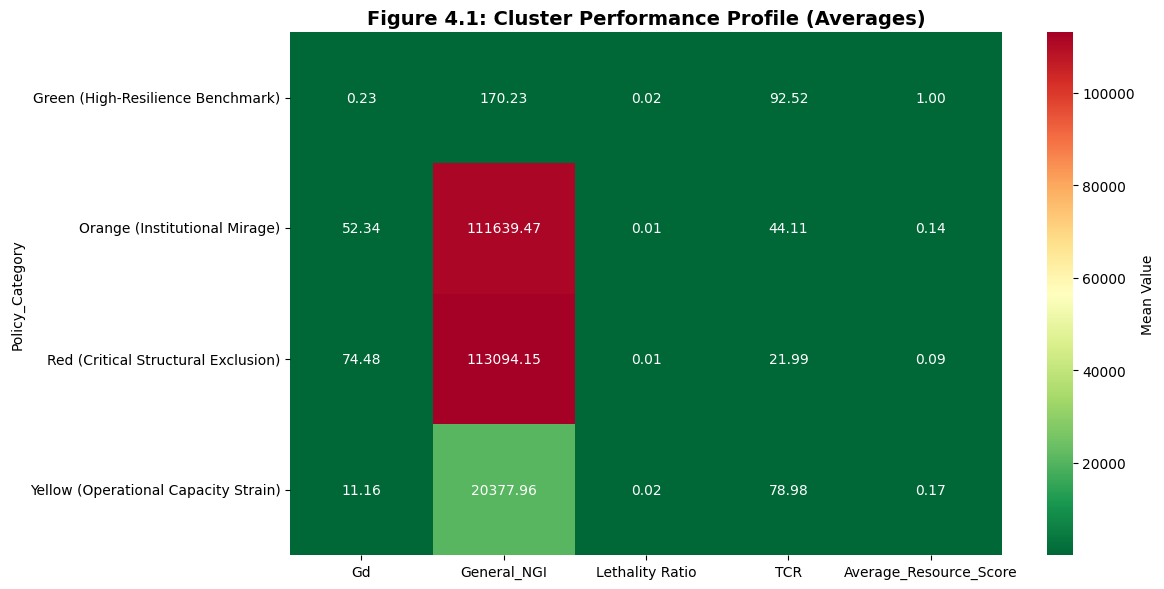

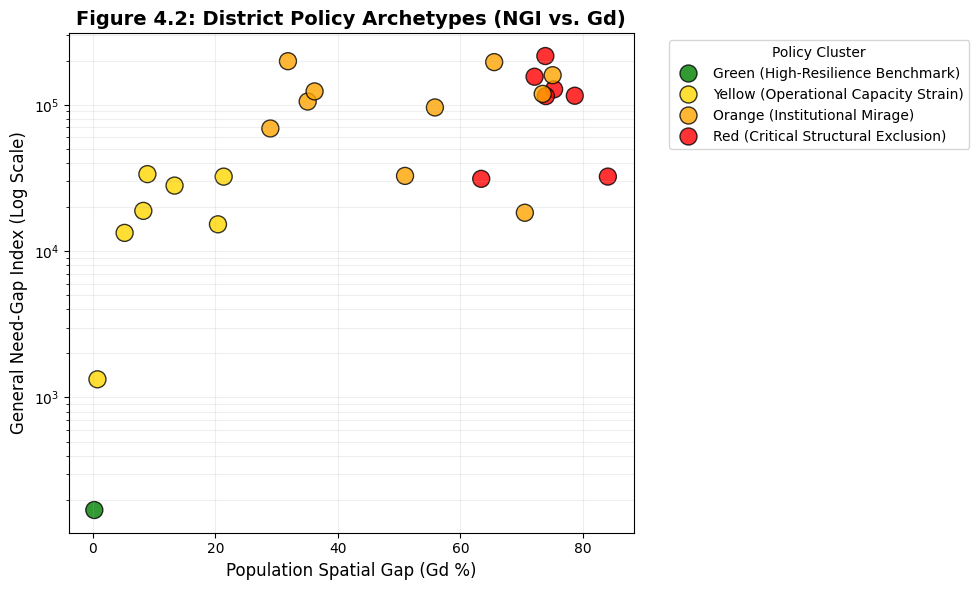

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
# Ensure your file is named 'Phase4_Check_1.csv'
df = pd.read_csv('Phase4_Check_1.csv')

# 2. FEATURE ENGINEERING: Territorial Coverage Ratio (TCR)
# Hexagon size is 0.737 km2. TCR is the % of land area covered by 1-hour service.
df['TCR'] = (df['Hex_Covered_1hr'] * 0.737 / df['District_Area_km2']) * 100
df['TCR'] = df['TCR'].clip(upper=100) # Cap at 100% for mathematical consistency

# 3. SELECT THE 5 PERFORMANCE DIMENSIONS
# Gd: Population Gap
# General_NGI: Systemic Pressure
# Lethality Ratio: Clinical Failure
# TCR: Land Gap
# Average_Resource_Score: Supply Strength
features = ['Gd', 'General_NGI', 'Lethality Ratio', 'TCR', 'Average_Resource_Score']
X = df[features]

# 4. STANDARDIZATION
# We scale the data so that large NGI numbers don't overwhelm small Lethality Ratios
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. EXECUTE K-MEANS CLUSTERING (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 6. ASSIGN POLICY CATEGORIES (Automatic Color Mapping)
# We calculate the mean of each cluster to identify which is 'Red', 'Green', etc.
cluster_means = df.groupby('Cluster_ID')[features].mean()

# Ranking by vulnerability (High Gd + High Lethality = Red)
cluster_means['Rank'] = cluster_means['Gd'] + (cluster_means['Lethality Ratio'] * 100)
sorted_indices = cluster_means.sort_values('Rank', ascending=False).index.tolist()

color_mapping = {
    sorted_indices[0]: 'Red (Critical Structural Exclusion)',
    sorted_indices[1]: 'Orange (Institutional Mirage)',
    sorted_indices[2]: 'Yellow (Operational Capacity Strain)',
    sorted_indices[3]: 'Green (High-Resilience Benchmark)'
}

df['Policy_Category'] = df['Cluster_ID'].map(color_mapping)

# 7. EXPORT RESULTS
df.to_csv('Phase4_Policy_Results.csv', index=False)
print("Phase 4 Clustering Complete. Results saved to 'Phase4_Policy_Results.csv'")

# 8. VISUALIZATION 1: Cluster Characteristics Heatmap
plt.figure(figsize=(12, 6))
summary = df.groupby('Policy_Category')[features].mean()
sns.heatmap(summary, annot=True, cmap='RdYlGn_r', fmt=".2f", cbar_kws={'label': 'Mean Value'})
plt.title('Figure 4.1: Cluster Performance Profile (Averages)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Phase4_Heatmap.png', dpi=300)

# 9. VISUALIZATION 2: Policy Scatter Plot
plt.figure(figsize=(10, 6))
# Define color palette to match categories
palette = {
    'Red (Critical Structural Exclusion)': 'red',
    'Orange (Institutional Mirage)': 'orange',
    'Yellow (Operational Capacity Strain)': 'gold',
    'Green (High-Resilience Benchmark)': 'green'
}

sns.scatterplot(data=df, x='Gd', y='General_NGI', hue='Policy_Category',
                palette=palette, s=150, edgecolor='black', alpha=0.8)

plt.yscale('log') # NGI is best viewed on a log scale
plt.title('Figure 4.2: District Policy Archetypes (NGI vs. Gd)', fontsize=14, fontweight='bold')
plt.xlabel('Population Spatial Gap (Gd %)', fontsize=12)
plt.ylabel('General Need-Gap Index (Log Scale)', fontsize=12)
plt.legend(title='Policy Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.savefig('Phase4_ScatterPlot.png', dpi=300)

plt.show()

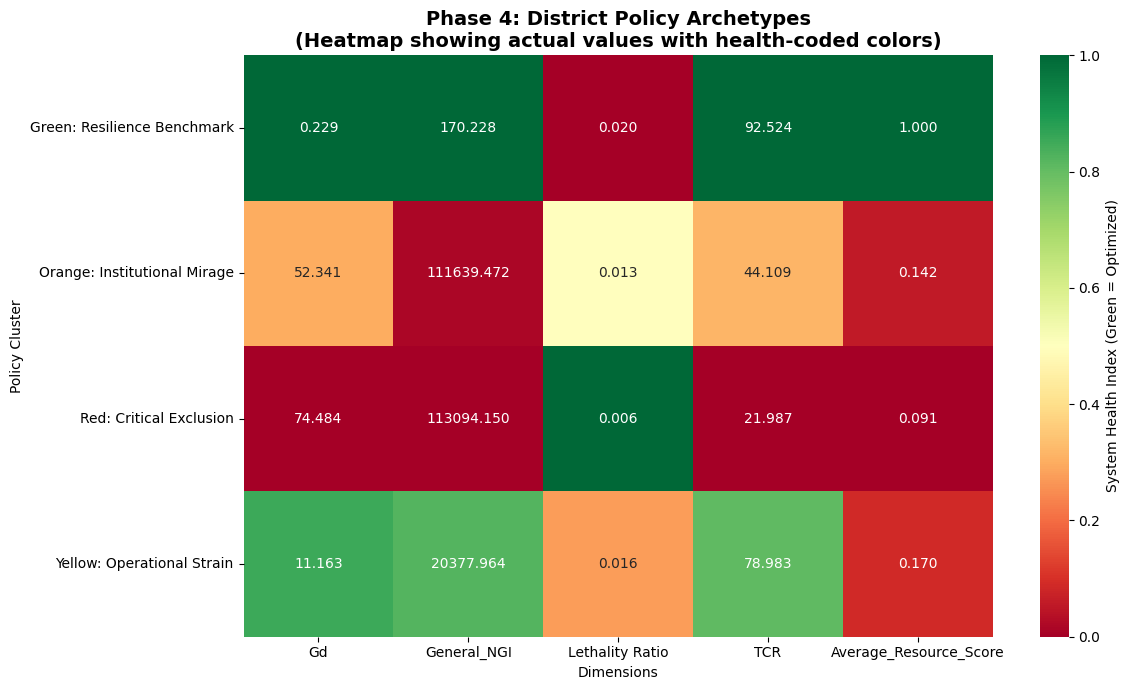

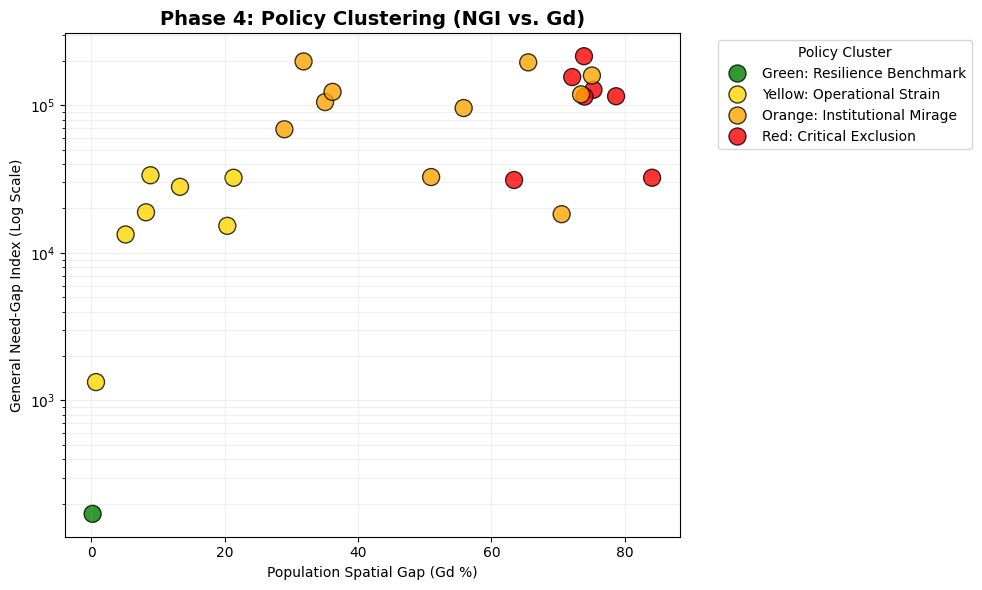

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. LOAD DATA
# Ensure the file 'Phase4_Check_1.csv' is in your working directory
df = pd.read_csv('Phase4_Check_1.csv')

# 2. FEATURE ENGINEERING: TCR (Territorial Coverage Ratio)
# Hexagon size = 0.737 km2. This represents land-based access.
df['TCR'] = (df['Hex_Covered_1hr'] * 0.737 / df['District_Area_km2']) * 100
df['TCR'] = df['TCR'].clip(upper=100) # Ensure it doesn't exceed 100%

# 3. DEFINE THE PERFORMANCE VECTOR (5 Dimensions)
features = ['Gd', 'General_NGI', 'Lethality Ratio', 'TCR', 'Average_Resource_Score']
X = df[features]

# 4. STANDARDIZATION
# Necessary for K-Means so that large NGI values don't drown out small Lethality Ratios
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. EXECUTE K-MEANS CLUSTERING (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 6. ASSIGN POLICY CATEGORIES (Automatic Color Mapping)
# We rank clusters by vulnerability (High Gd + High Lethality = Red)
cluster_means = df.groupby('Cluster_ID')[features].mean()
cluster_means['Rank'] = cluster_means['Gd'] + (cluster_means['Lethality Ratio'] * 100)
sorted_indices = cluster_means.sort_values('Rank', ascending=False).index.tolist()

color_mapping = {
    sorted_indices[0]: 'Red: Critical Exclusion',
    sorted_indices[1]: 'Orange: Institutional Mirage',
    sorted_indices[2]: 'Yellow: Operational Strain',
    sorted_indices[3]: 'Green: Resilience Benchmark'
}
df['Policy_Category'] = df['Cluster_ID'].map(color_mapping)

# Save Final Results Table
df.to_csv('Phase4_Final_Policy_Results.csv', index=False)

# 7. VISUALIZATION 1: FINAL POLICY HEATMAP (Red-Yellow-Green)
# This normalization ensures that Green = "Healthy/Good" and Red = "Deficient/Risk"
summary = df.groupby('Policy_Category')[features].mean()
summary_norm = (summary - summary.min()) / (summary.max() - summary.min())

# Flip metrics where "Low is Good" (Gd, NGI, Lethality)
# Keep metrics where "High is Good" (TCR, Resource Score)
vis_df = summary_norm.copy()
vis_df['Gd'] = 1 - summary_norm['Gd']
vis_df['General_NGI'] = 1 - summary_norm['General_NGI']
vis_df['Lethality Ratio'] = 1 - summary_norm['Lethality Ratio']

plt.figure(figsize=(12, 7))
sns.heatmap(vis_df, annot=summary, cmap='RdYlGn', fmt=".3f",
            cbar_kws={'label': 'System Health Index (Green = Optimized)'})
plt.title('Phase 4: District Policy Archetypes\n(Heatmap showing actual values with health-coded colors)', fontsize=14, fontweight='bold')
plt.xlabel('Dimensions')
plt.ylabel('Policy Cluster')
plt.tight_layout()
plt.savefig('Phase4_Final_Heatmap.png', dpi=300)

# 8. VISUALIZATION 2: POLICY SCATTER PLOT
plt.figure(figsize=(10, 6))
palette = {
    'Red: Critical Exclusion': 'red',
    'Orange: Institutional Mirage': 'orange',
    'Yellow: Operational Strain': 'gold',
    'Green: Resilience Benchmark': 'green'
}

sns.scatterplot(data=df, x='Gd', y='General_NGI', hue='Policy_Category',
                palette=palette, s=150, edgecolor='black', alpha=0.8)

plt.yscale('log') # Log scale for NGI clarity
plt.title('Phase 4: Policy Clustering (NGI vs. Gd)', fontsize=14, fontweight='bold')
plt.xlabel('Population Spatial Gap (Gd %)')
plt.ylabel('General Need-Gap Index (Log Scale)')
plt.legend(title='Policy Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.savefig('Phase4_Final_ScatterPlot.png', dpi=300)

plt.show()

Simulation complete.
The national systemic pressure was reduced by 9.65%
Results saved to 'Phase4_Optimization_Impact_Table.csv'


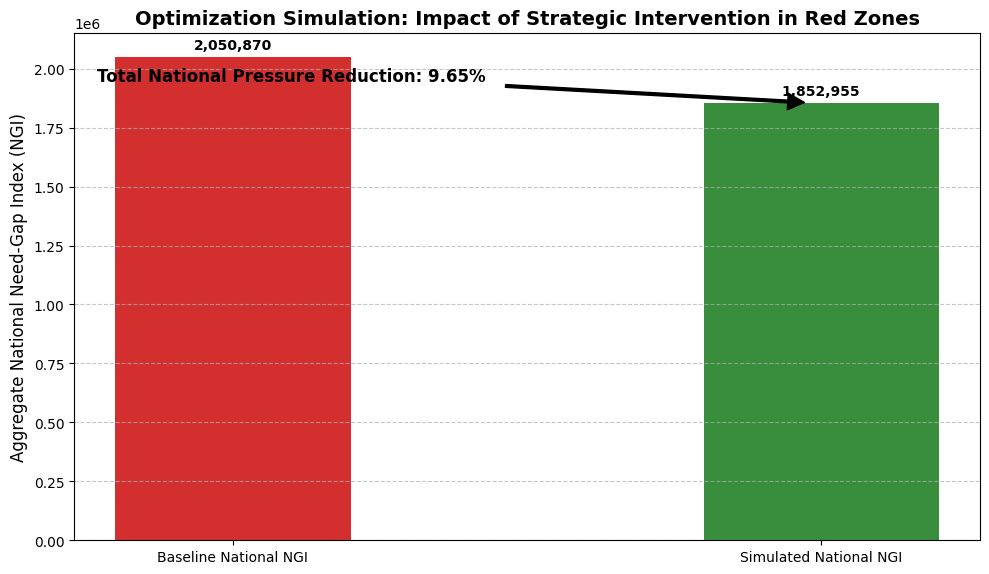

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD THE CLUSTERING RESULTS
# Ensure 'Phase4_Final_Policy_Results.csv' (generated in the previous step) is in your folder
df = pd.read_csv('Phase4_Final_Policy_Results.csv')

# 2. DEFINE THE SIMULATION PARAMETERS
# We assume a strategic intervention (new hospital/ETU) reduces the Gap (Gd) by 25%
REDUCTION_FACTOR = 0.25

# 3. RUN THE SIMULATION FOR RED DISTRICTS
# Filter only the districts in the "Red: Critical Exclusion" category
red_mask = df['Policy_Category'] == 'Red: Critical Exclusion'
red_districts = df[red_mask].copy()

# Calculate the new values
# In our methodology, General_NGI is directly proportional to Gd
red_districts['Simulated_Gd'] = red_districts['Gd'] * (1 - REDUCTION_FACTOR)
red_districts['Simulated_NGI'] = red_districts['General_NGI'] * (1 - REDUCTION_FACTOR)
red_districts['NGI_Reduction_Value'] = red_districts['General_NGI'] - red_districts['Simulated_NGI']

# 4. CALCULATE NATIONAL IMPACT
total_baseline_ngi = df['General_NGI'].sum()

# Sum of NGI from non-red districts + the new simulated NGI for red districts
total_simulated_ngi = (df[~red_mask]['General_NGI'].sum() +
                       red_districts['Simulated_NGI'].sum())

national_reduction_pct = ((total_baseline_ngi - total_simulated_ngi) / total_baseline_ngi) * 100

# 5. CREATE THE OUTPUT TABLE
simulation_table = red_districts[['District', 'Gd', 'Simulated_Gd', 'General_NGI', 'Simulated_NGI', 'NGI_Reduction_Value']]
simulation_table.columns = ['District', 'Baseline Gd (%)', 'Simulated Gd (%)', 'Baseline NGI', 'Simulated NGI', 'NGI Relief']

# Save the table for your thesis appendix
simulation_table.to_csv('Phase4_Optimization_Impact_Table.csv', index=False)

# 6. VISUALIZATION: IMPACT CHART
plt.figure(figsize=(10, 6))
labels = ['Baseline National NGI', 'Simulated National NGI']
values = [total_baseline_ngi, total_simulated_ngi]

# Creating the bar chart
bars = plt.bar(labels, values, color=['#d32f2f', '#388e3c'], width=0.4)

# Adding labels and titles
plt.title('Optimization Simulation: Impact of Strategic Intervention in Red Zones', fontsize=14, fontweight='bold')
plt.ylabel('Aggregate National Need-Gap Index (NGI)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (total_baseline_ngi * 0.01),
             f'{height:,.0f}', ha='center', va='bottom', fontweight='bold')

# Add the "Improvement Arrow"
plt.annotate(f'Total National Pressure Reduction: {national_reduction_pct:.2f}%',
             xy=(1, total_simulated_ngi), xytext=(0.1, total_baseline_ngi * 0.95),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2),
             ha='center', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('Phase4_Simulation_Impact_Chart_new.png', dpi=300)

print("Simulation complete.")
print(f"The national systemic pressure was reduced by {national_reduction_pct:.2f}%")
print("Results saved to 'Phase4_Optimization_Impact_Table.csv'")

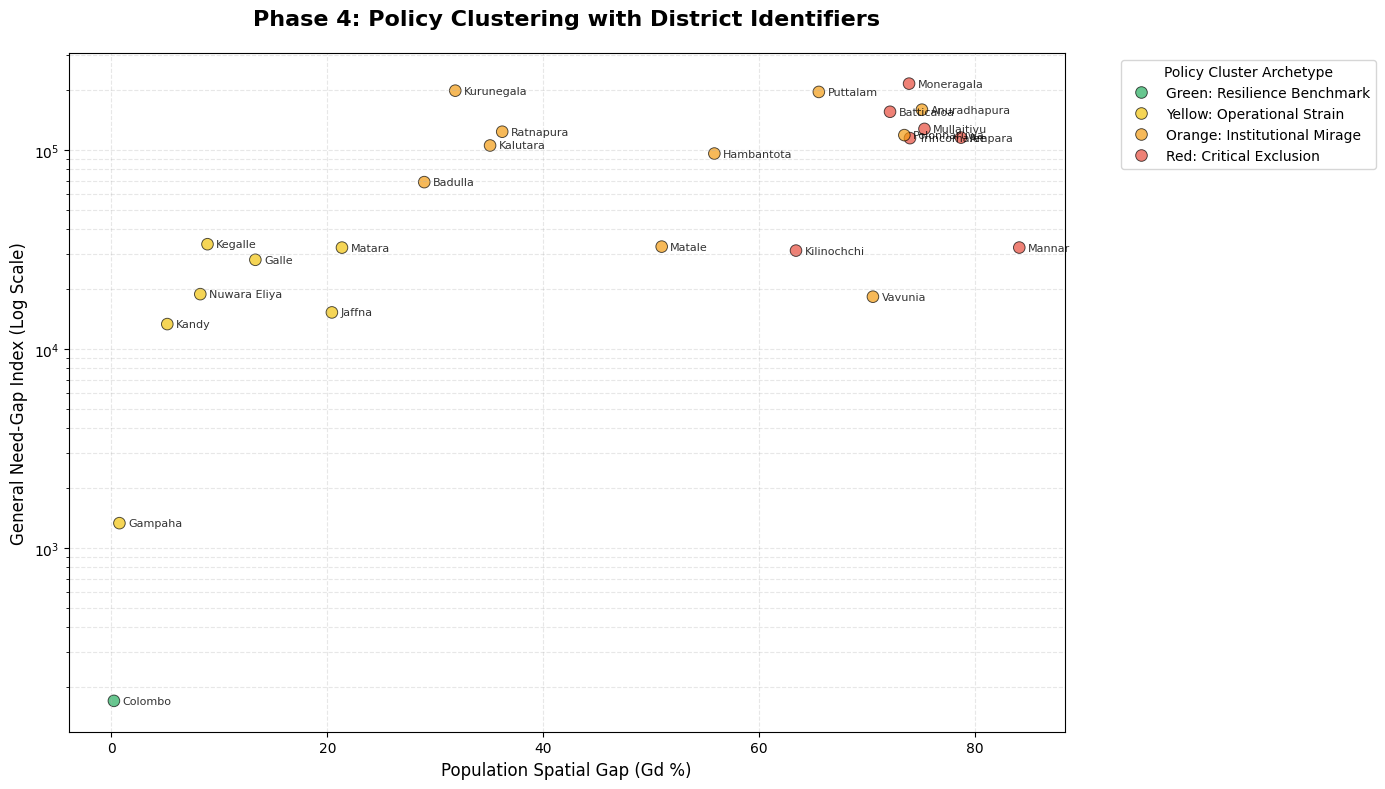

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. LOAD DATA
df = pd.read_csv('Phase4_Check_1.csv')

# 2. FEATURE ENGINEERING: TCR (Territorial Coverage Ratio)
df['TCR'] = (df['Hex_Covered_1hr'] * 0.737 / df['District_Area_km2']) * 100
df['TCR'] = df['TCR'].clip(upper=100)

# 3. DEFINE THE PERFORMANCE VECTOR
features = ['Gd', 'General_NGI', 'Lethality Ratio', 'TCR', 'Average_Resource_Score']
X = df[features]

# 4. STANDARDIZATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. EXECUTE K-MEANS CLUSTERING (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 6. ASSIGN POLICY CATEGORIES
cluster_means = df.groupby('Cluster_ID')[features].mean()
cluster_means['Rank'] = cluster_means['Gd'] + (cluster_means['Lethality Ratio'] * 100)
sorted_indices = cluster_means.sort_values('Rank', ascending=False).index.tolist()

color_mapping = {
    sorted_indices[0]: 'Red: Critical Exclusion',
    sorted_indices[1]: 'Orange: Institutional Mirage',
    sorted_indices[2]: 'Yellow: Operational Strain',
    sorted_indices[3]: 'Green: Resilience Benchmark'
}
df['Policy_Category'] = df['Cluster_ID'].map(color_mapping)

# Save Final Results
df.to_csv('Phase4_Final_Policy_Results.csv', index=False)

# 7. UPDATED VISUALIZATION: POLICY SCATTER PLOT WITH DISTRICT NAMES
plt.figure(figsize=(14, 8)) # Increased size for better label visibility
palette = {
    'Red: Critical Exclusion': '#e74c3c',   # Professional Red
    'Orange: Institutional Mirage': '#f39c12', # Professional Orange
    'Yellow: Operational Strain': '#f1c40f', # Professional Yellow/Gold
    'Green: Resilience Benchmark': '#27ae60' # Professional Green
}

# Reduced marker size (s=70) for a cleaner look
ax = sns.scatterplot(data=df, x='Gd', y='General_NGI', hue='Policy_Category',
                palette=palette, s=70, edgecolor='black', alpha=0.7)

# --- ADDING DISTRICT LABELS ---
# We loop through the dataframe to place the name of each district
for i in range(df.shape[0]):
    plt.text(x=df.Gd.iloc[i] + 0.8, # Small x-offset so text doesn't touch the dot
             y=df.General_NGI.iloc[i],
             s=df['District'].iloc[i], # Assuming column name is 'District'
             fontsize=8,
             alpha=0.8,
             verticalalignment='center')

plt.yscale('log') # Log scale for NGI clarity
plt.title('Phase 4: Policy Clustering with District Identifiers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Population Spatial Gap (Gd %)', fontsize=12)
plt.ylabel('General Need-Gap Index (Log Scale)', fontsize=12)
plt.legend(title='Policy Cluster Archetype', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save the high-quality figure
plt.savefig('Phase4_Final_ScatterPlot_Named.png', dpi=300)
plt.show()

In [3]:
!pip install adjust_text

ERROR: Could not find a version that satisfies the requirement adjust_text (from versions: none)
ERROR: No matching distribution found for adjust_text


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from adjust_text import adjust_text # <-- The magic fix for overlapping labels

# 1. LOAD DATA
df = pd.read_csv('Phase4_Check_1.csv')

# 2. FEATURE ENGINEERING & CLUSTERING (Same as your logic)
df['TCR'] = (df['Hex_Covered_1hr'] * 0.737 / df['District_Area_km2']) * 100
df['TCR'] = df['TCR'].clip(upper=100)

features = ['Gd', 'General_NGI', 'Lethality Ratio', 'TCR', 'Average_Resource_Score']
X_scaled = StandardScaler().fit_transform(df[features])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 3. ASSIGN VIVID POLICY CATEGORIES
cluster_means = df.groupby('Cluster_ID')[features].mean()
cluster_means['Rank'] = cluster_means['Gd'] + (cluster_means['Lethality Ratio'] * 100)
sorted_indices = cluster_means.sort_values('Rank', ascending=False).index.tolist()

color_mapping = {
    sorted_indices[0]: 'Red: Critical Exclusion',
    sorted_indices[1]: 'Orange: Institutional Mirage',
    sorted_indices[2]: 'Yellow: Operational Strain',
    sorted_indices[3]: 'Green: Resilience Benchmark'
}
df['Policy_Category'] = df['Cluster_ID'].map(color_mapping)

# 4. PLOTTING WITH VIVID COLORS AND SMART LABELS
plt.figure(figsize=(14, 9))

# Using high-saturation/bright versions of your colors
palette = {
    'Red: Critical Exclusion': '#FF0000',      # Bright Pure Red
    'Orange: Institutional Mirage': '#FF8C00', # Vivid Dark Orange
    'Yellow: Operational Strain': '#FFD700',   # Bright Gold
    'Green: Resilience Benchmark': '#00C853'   # High-Vibrancy Green
}

# Smaller markers to reduce clutter (s=60)
sns.scatterplot(data=df, x='Gd', y='General_NGI', hue='Policy_Category',
                palette=palette, s=60, edgecolor='black', linewidth=1, alpha=0.9)

# --- SMART ANNOTATION ENGINE ---
texts = []
for i in range(df.shape[0]):
    # Create list of text objects
    texts.append(plt.text(df.Gd.iloc[i], df.General_NGI.iloc[i],
                 df['District'].iloc[i], # Change to your column name
                 fontsize=9,
                 fontweight='bold', # Increased weight for visibility
                 color='black'))

# This function automatically moves labels to prevent overlap
# arrowprops draws a tiny line if the name is moved far from the dot
adjust_text(texts,
            only_move={'points':'y', 'texts':'xy'},
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.yscale('log')
plt.title('Phase 4: Policy Clustering (Optimized for Readability)', fontsize=16, fontweight='bold')
plt.xlabel('Population Spatial Gap (Gd %)', fontsize=12, fontweight='bold')
plt.ylabel('General Need-Gap Index (Log Scale)', fontsize=12, fontweight='bold')
plt.legend(title='Policy Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig('Phase4_Clean_ScatterPlot.png', dpi=300)
plt.show()

ModuleNotFoundError: No module named 'adjust_text'

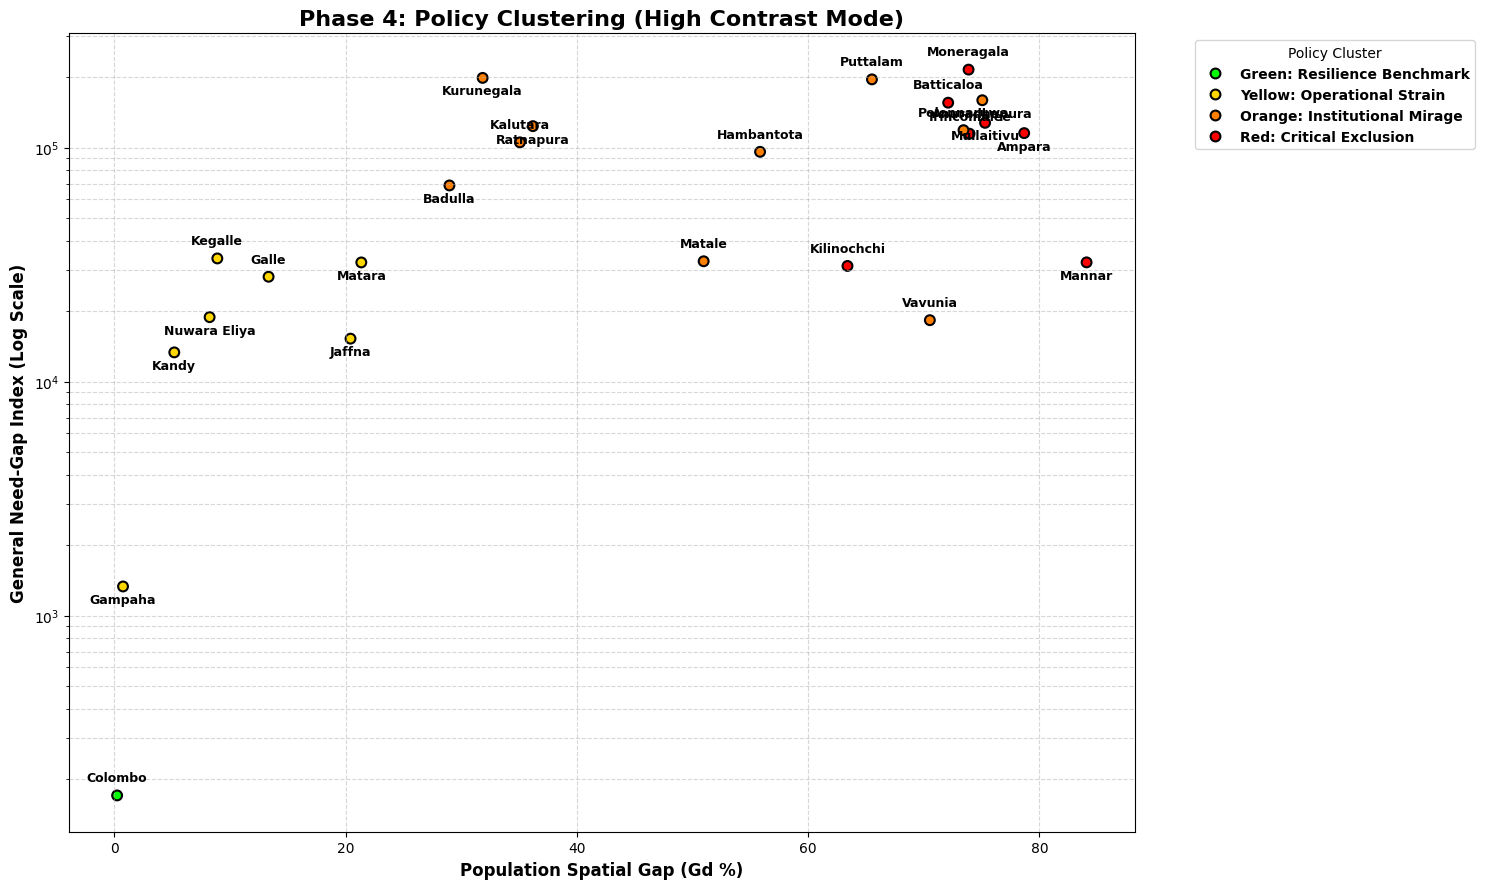

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Keep your loading and clustering code the same until the plot) ...

plt.figure(figsize=(15, 9))

# High-Vibrancy Palette
palette = {
    'Red: Critical Exclusion': '#FF0000',      # Pure Bright Red
    'Orange: Institutional Mirage': '#FF7F00', # Vivid Orange
    'Yellow: Operational Strain': '#FFD700',   # Bright Gold
    'Green: Resilience Benchmark': '#00FF00'   # Neon Green
}

# Smaller markers to leave room for text
sns.scatterplot(data=df, x='Gd', y='General_NGI', hue='Policy_Category',
                palette=palette, s=50, edgecolor='black', linewidth=1.5, alpha=1.0)

# --- MANUAL OFFSET LOGIC (No library needed) ---
for i in range(df.shape[0]):
    district = df['District'].iloc[i]
    x = df.Gd.iloc[i]
    y = df.General_NGI.iloc[i]

    # Staggering logic: If NGI is high, move label up; if low, move it down
    # This helps separate overlapping names like Anuradhapura and Polonnaruwa
    y_offset = 1.15 if i % 2 == 0 else 0.85

    plt.text(x, y * y_offset, district,
             fontsize=9,
             fontweight='bold',
             color='black',
             horizontalalignment='center')

plt.yscale('log')
plt.title('Phase 4: Policy Clustering (High Contrast Mode)', fontsize=16, fontweight='bold')
plt.xlabel('Population Spatial Gap (Gd %)', fontsize=12, fontweight='bold')
plt.ylabel('General Need-Gap Index (Log Scale)', fontsize=12, fontweight='bold')
plt.legend(title='Policy Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', prop={'weight':'bold'})
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

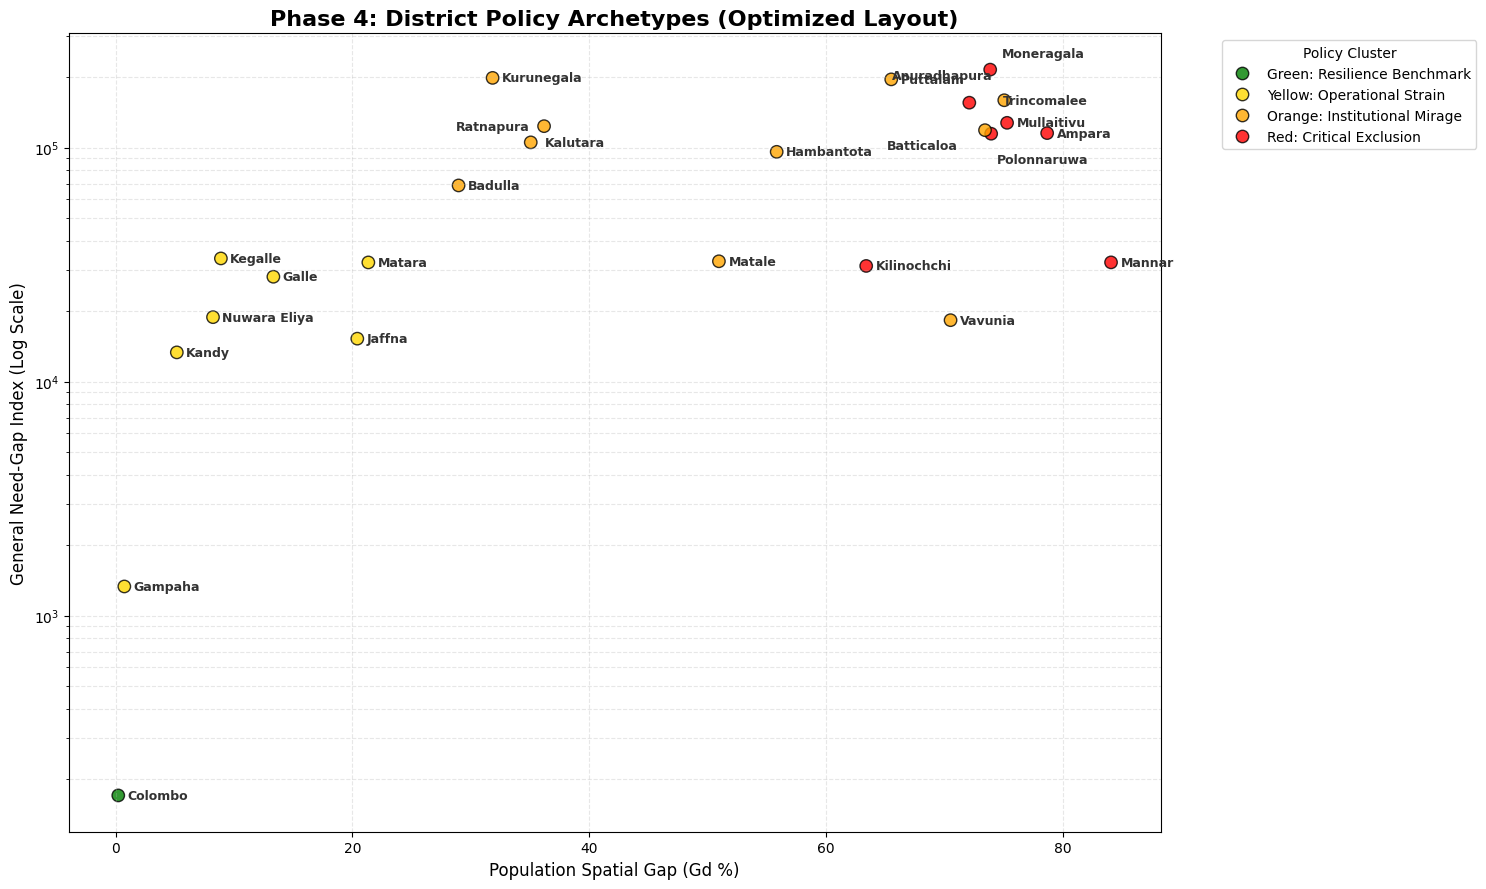

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Your loading and clustering code remains the same) ...

plt.figure(figsize=(15, 9))

# Reverting to your original professional colors (standard Hex)
palette = {
    'Red: Critical Exclusion': 'red',
    'Orange: Institutional Mirage': 'orange',
    'Yellow: Operational Strain': 'gold',
    'Green: Resilience Benchmark': 'green'
}

# Standard professional scatter
sns.scatterplot(data=df, x='Gd', y='General_NGI', hue='Policy_Category',
                palette=palette, s=80, edgecolor='black', linewidth=1, alpha=0.8)

# --- INDIVIDUAL LABEL POSITIONING ENGINE ---
for i in range(df.shape[0]):
    district = df['District'].iloc[i]
    x = df.Gd.iloc[i]
    y = df.General_NGI.iloc[i]

    # Default offsets
    ha = 'left'
    va = 'center'
    x_off = 0.8
    y_off = 1.0  # Multiplier for Log scale

    # --- SPECIFIC ADJUSTMENTS FOR OVERLAPS ---
    if district == 'Anuradhapura':
        ha, va, x_off, y_off = 'right', 'bottom', -1.0, 1.2
    elif district == 'Polonnaruwa':
        ha, va, x_off, y_off = 'left', 'top', 1.0, 0.8
    elif district == 'Trincomalee':
        ha, va, x_off, y_off = 'left', 'bottom', 1.0, 1.3
    elif district == 'Kalutara':
        ha, va, x_off, y_off = 'left', 'center', 1.2, 1.0 # Pushed right off the dot
    elif district == 'Ratnapura':
        ha, va, x_off, y_off = 'right', 'center', -1.2, 1.0 # Pushed left off the dot
    elif district == 'Moneragala':
        ha, va, x_off, y_off = 'left', 'bottom', 1.0, 1.1
    elif district == 'Batticaloa':
        ha, va, x_off, y_off = 'right', 'top', -1.0, 0.7

    plt.text(x + x_off, y * y_off, district,
             fontsize=9,
             fontweight='bold',
             color='#333333',
             horizontalalignment=ha,
             verticalalignment=va)

plt.yscale('log')
plt.title('Phase 4: District Policy Archetypes (Optimized Layout)', fontsize=16, fontweight='bold')
plt.xlabel('Population Spatial Gap (Gd %)', fontsize=12)
plt.ylabel('General Need-Gap Index (Log Scale)', fontsize=12)
plt.legend(title='Policy Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

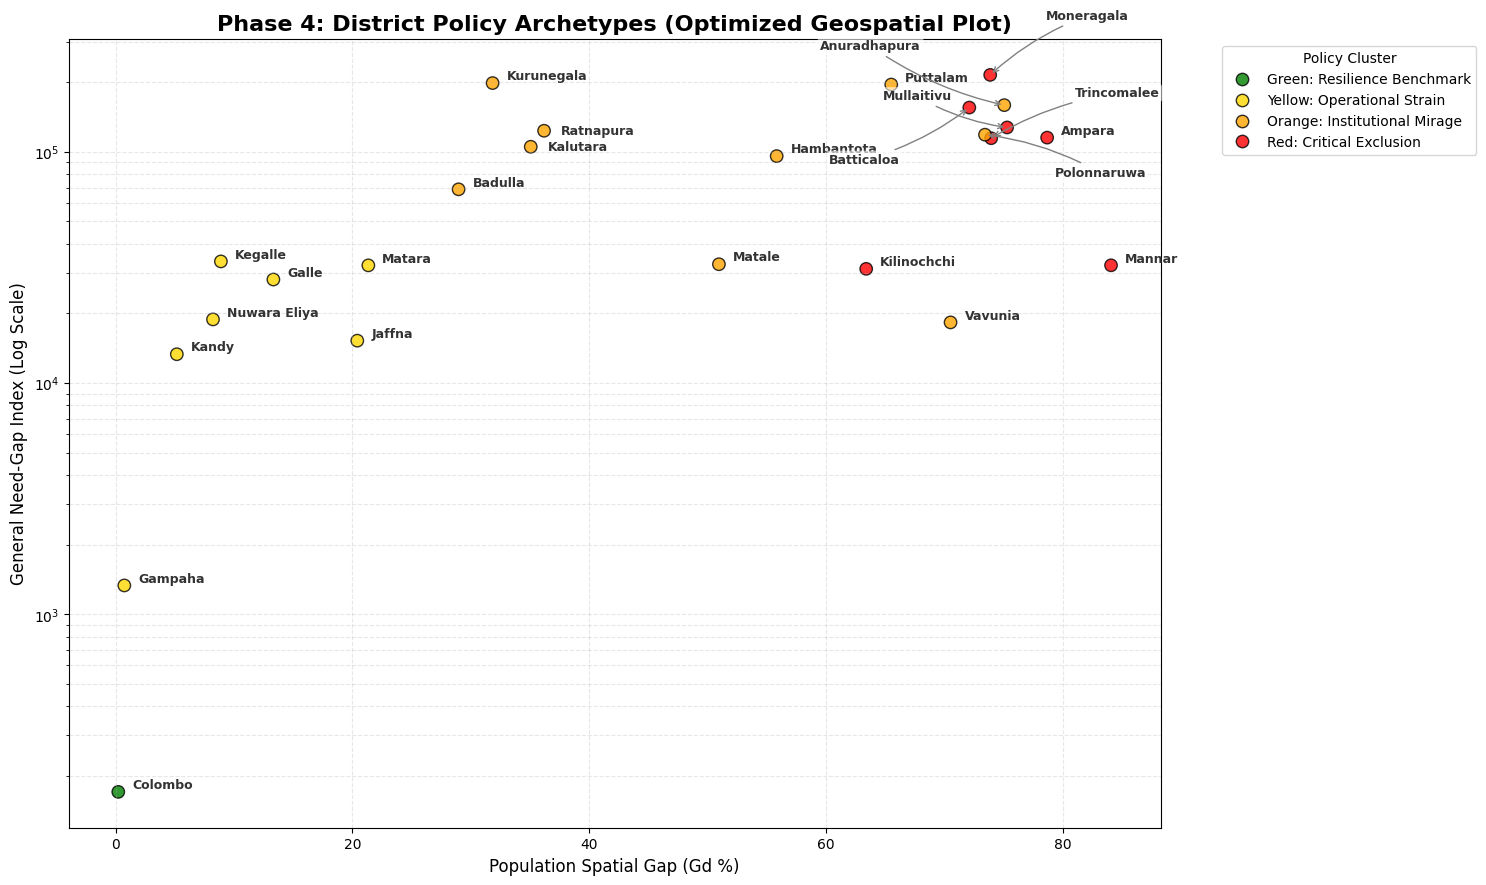

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Loading and clustering code remains same) ...

plt.figure(figsize=(15, 9))

# Original professional colors
palette = {
    'Red: Critical Exclusion': 'red',
    'Orange: Institutional Mirage': 'orange',
    'Yellow: Operational Strain': 'gold',
    'Green: Resilience Benchmark': 'green'
}

sns.scatterplot(data=df, x='Gd', y='General_NGI', hue='Policy_Category',
                palette=palette, s=80, edgecolor='black', linewidth=1, alpha=0.8)

# --- INDIVIDUAL ANNOTATION ENGINE ---
for i in range(df.shape[0]):
    district = df['District'].iloc[i]
    x = df.Gd.iloc[i]
    y = df.General_NGI.iloc[i]

    # Default: Standard text placement for non-congested areas
    ha, va = 'left', 'bottom'
    xytext = (10, 5) # 10 points right, 5 points up

    # --- HARD-CODED "SMART" OFFSETS FOR THE CONGESTED CLUSTER ---
    # These move the text and draw an arrow back to the dot
    use_arrow = False

    if district == 'Anuradhapura':
        xytext, ha, use_arrow = (-60, 40), 'right', True
    elif district == 'Polonnaruwa':
        xytext, ha, use_arrow = (50, -30), 'left', True
    elif district == 'Trincomalee':
        xytext, ha, use_arrow = (60, 30), 'left', True
    elif district == 'Batticaloa':
        xytext, ha, use_arrow = (-50, -40), 'right', True
    elif district == 'Moneragala':
        xytext, ha, use_arrow = (40, 40), 'left', True
    elif district == 'Mullaitivu':
        xytext, ha, use_arrow = (-40, 20), 'right', True
    elif district in ['Kalutara', 'Ratnapura']:
        xytext, ha = (12, 0), 'left' # Simple push away

    if use_arrow:
        plt.annotate(district, xy=(x, y), xytext=xytext,
                     textcoords='offset points', ha=ha,
                     fontweight='bold', fontsize=9, color='#333333',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'),
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', color='gray'))
    else:
        plt.annotate(district, xy=(x, y), xytext=xytext,
                     textcoords='offset points', ha=ha, va='center',
                     fontweight='bold', fontsize=9, color='#333333')

plt.yscale('log')
plt.title('Phase 4: District Policy Archetypes (Optimized Geospatial Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Population Spatial Gap (Gd %)', fontsize=12)
plt.ylabel('General Need-Gap Index (Log Scale)', fontsize=12)
plt.legend(title='Policy Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()